In [21]:
# Sirf important columns select karo Dashboard ke liye
dashboard_df = df[[
    'Order Id', 'order date (DateOrders)', 'Order Region', 'Order Country',
    'Category Name', 'Customer Segment', 'Shipping Mode',
    'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Late_delivery_risk', 'Delivery Status',
    'Sales per customer', 'Benefit per order', 'Order Item Quantity'
]]

# Clean CSV save karo
dashboard_df.to_csv('clean_supply_chain.csv', index=False)

print("Clean file ban gayi! ✅")
print(dashboard_df.shape)

Clean file ban gayi! ✅
(180519, 14)


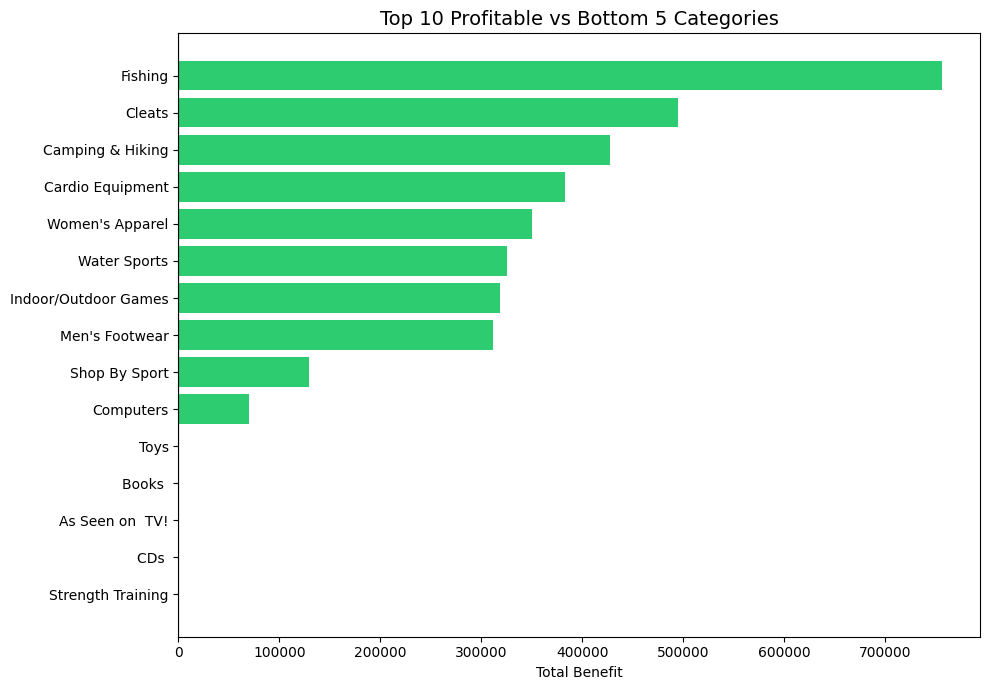

In [20]:
# Top 10 Profit + Bottom 5 Loss categories - CLEAN chart
category_profit = df.groupby('Category Name')['Benefit per order'].sum().sort_values(ascending=False)

top10 = category_profit.head(10)
bottom5 = category_profit.tail(5)
combined = pd.concat([top10, bottom5])

plt.figure(figsize=(10,7))
colors = ['#2ECC71' if x in top10.values else '#E74C3C' for x in combined.values]
plt.barh(combined.index[::-1], combined.values[::-1], color=colors[::-1])
plt.title('Top 10 Profitable vs Bottom 5 Categories', fontsize=14)
plt.xlabel('Total Benefit')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

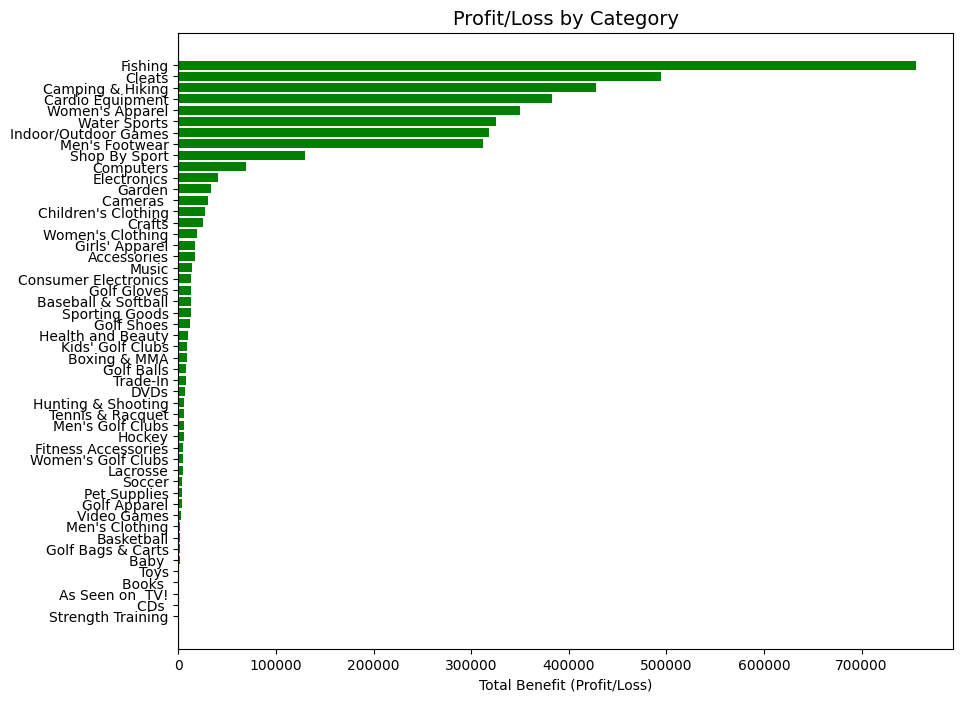

In [19]:
# Top 10 most profitable + Top 5 loss-making categories
category_profit = df.groupby('Category Name')['Benefit per order'].sum().sort_values()

plt.figure(figsize=(10,8))
colors = ['red' if x < 0 else 'green' for x in category_profit.values]
plt.barh(category_profit.index, category_profit.values, color=colors)
plt.title('Profit/Loss by Category', fontsize=14)
plt.xlabel('Total Benefit (Profit/Loss)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.show()

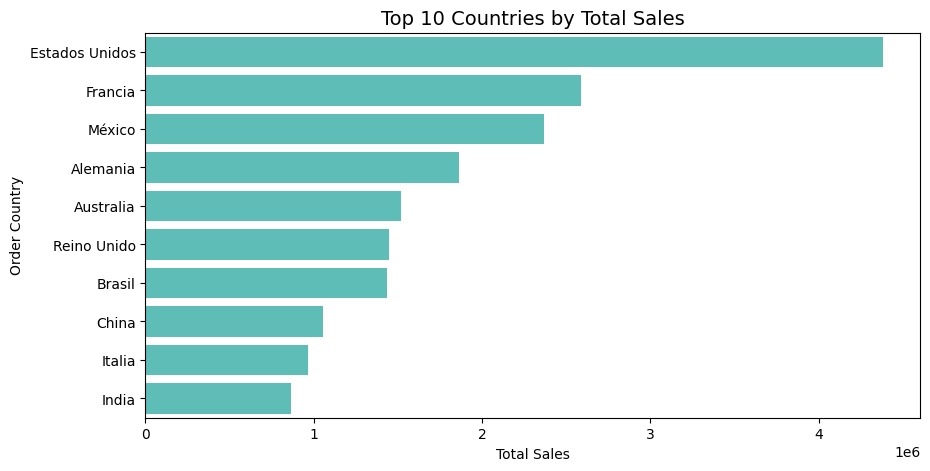

In [18]:
# Top 10 countries by total sales
country_sales = df.groupby('Order Country')['Sales per customer'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=country_sales.values, y=country_sales.index, color='#4ECDC4')
plt.title('Top 10 Countries by Total Sales', fontsize=14)
plt.xlabel('Total Sales')
plt.show()

In [17]:
# Kaunsi product category sabse zyada LOSS de rahi hai?
category_loss = df.groupby('Category Name')['Benefit per order'].sum().sort_values()

print("Top 5 LOSS-making categories:")
print(category_loss.head())

print("\nTop 5 PROFIT-making categories:")
print(category_loss.tail())

Top 5 LOSS-making categories:
Category Name
Strength Training    332.310091
CDs                  383.850000
As Seen on  TV!      714.429980
Books                883.010008
Toys                 900.710000
Name: Benefit per order, dtype: float64

Top 5 PROFIT-making categories:
Category Name
Women's Apparel     350421.029567
Cardio Equipment    383011.098485
Camping & Hiking    427455.568106
Cleats              494636.919791
Fishing             756220.767190
Name: Benefit per order, dtype: float64


In [16]:
# Kaunse Region mein sabse zyada late delivery hoti hai?
df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False)

Order Region
Central Africa     0.579606
South Asia         0.562670
East Africa        0.559395
Western Europe     0.558486
South of  USA      0.557726
Eastern Europe     0.556633
East of USA        0.556616
Southeast Asia     0.555299
Central Asia       0.553345
West Asia          0.552837
US Center          0.552404
Central America    0.547546
North Africa       0.545173
Southern Europe    0.543845
Eastern Asia       0.543269
South America      0.543087
Northern Europe    0.540441
Oceania            0.540205
West of USA        0.539597
Southern Africa    0.533276
Caribbean          0.530777
West Africa        0.528409
Canada             0.488008
Name: Late_delivery_risk, dtype: float64

C:\Users\Dell\AppData\Local\Temp\ipykernel_18860\1363232876.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shipping_delay.index, y=shipping_delay.values, palette='Reds_r')


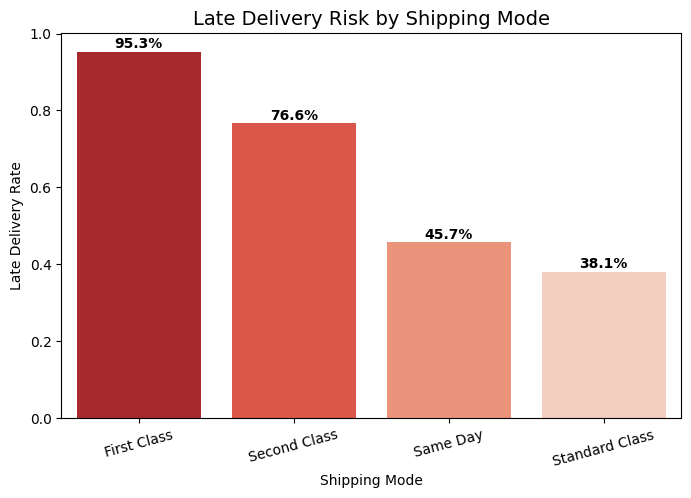

In [15]:
# Shipping Mode vs Late Delivery — Bar Chart
shipping_delay = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=shipping_delay.index, y=shipping_delay.values, palette='Reds_r')
plt.title('Late Delivery Risk by Shipping Mode', fontsize=14)
plt.ylabel('Late Delivery Rate')
plt.xlabel('Shipping Mode')
plt.xticks(rotation=15)

# Percentage labels upar dikhane ke liye
for i, v in enumerate(shipping_delay.values):
    plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontweight='bold')

plt.show()

In [14]:
# Kaunsa Shipping Mode sabse zyada late karta hai?
df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)

Shipping Mode
First Class       0.953225
Second Class      0.766328
Same Day          0.457430
Standard Class    0.380717
Name: Late_delivery_risk, dtype: float64

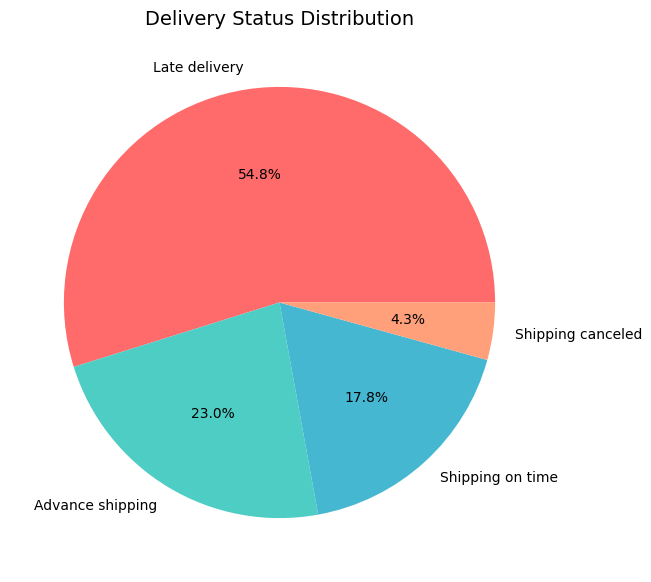

In [13]:
# Delivery Status ka Pie Chart banao
status_counts = df['Delivery Status'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
plt.title('Delivery Status Distribution', fontsize=14)
plt.show()

In [12]:
# Delivery Status ke kitne types hain aur kitni baar aaye
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [11]:
# Saare column names dekho
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [10]:
# Pehli 5 rows dekho
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [9]:
# Dataset load karo
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')

print("Dataset load ho gaya! ✅")
print("Total Rows   :", df.shape[0])
print("Total Columns:", df.shape[1])

Dataset load ho gaya! ✅
Total Rows   : 180519
Total Columns: 53


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries load ho gayi! ✅")

Libraries load ho gayi! ✅
